In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import hmean, gmean

In [2]:
plt.rcParams['figure.figsize'] = (8, 8)

 # Загрузка данных

In [3]:
data_file = Path.cwd() / 'data' / 'ozon_report.csv'
df = pd.read_csv(data_file, skiprows=[0,1,2,3,5])
print(df.head())


                                     Название товара  \
0  Электрическая гирлянда Ретро лампочки накалива...   
1     Необычный и оригинальный подарок. Сюрприз бокс   
2  Электрическая Ретро гирлянда с лампочками нака...   
3  Электрическая Ретро гирлянда с лампочками нака...   
4                                    Гелий для шаров   

                          Ссылка на товар          Продавец  \
0  https://www.ozon.ru/product/1746231495  Fashion Republic   
1  https://www.ozon.ru/product/1750905394             SMILE   
2  https://www.ozon.ru/product/2169632405       Love & Care   
3  https://www.ozon.ru/product/2165186762       Love & Care   
4  https://www.ozon.ru/product/2183675812          30sharov   

                              Бренд Категория 1 уровня Категория 3 уровня  \
0                            TEWSON          Дом и сад    Электрогирлянда   
1                        без бренда          Дом и сад    Елочная игрушка   
2                           NY CLUB          Дом и са

 # Очистка данных

In [4]:
df.describe()

,"Заказано на сумму, ₽","Заказано, штуки","Средняя цена, ₽","Минимальная цена, ₽","Доля выкупа, %","Упущенные продажи, ₽","Среднесуточные продажи, ₽","Среднесуточные продажи, штуки","Остаток на конец периода, штуки","Объем товара, л",Показы всего,Просмотры в поиске и каталоге,Просмотры карточки,"Конверсия из показа в заказ, %","В корзину из поиска и каталога, %","В корзину из карточки, %",Скидка за счет акций,"Доля оборота в акциях, %","Доля рекламных расходов, %"
count,1.000000e+03,1000.00000,1000.000000,1000.00000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.104071e+05,426.20400,2075.627000,1920.46800,89.004500,1.876803e+04,7499.632000,14.402000,4291.91200,7.352600,2.142157e+05,66537.032000,8156.477000,0.317290,0.518290,10.076390,22.628400,58.814600,7.031000
std,4.176215e+05,656.92792,5612.534638,5478.42398,7.098271,1.977724e+05,12635.117809,21.971097,63184.46054,21.565317,3.496605e+05,65242.956802,10780.963788,0.433976,0.433619,3.861728,22.199994,45.744236,8.548327
min,1.317300e+05,2.00000,111.000000,19.00000,20.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,2.510000e+02,73.000000,33.000000,0.010000,0.000000,2.260000,0.000000,0.000000,0.000000
25%,1.600782e+05,134.75000,441.750000,394.75000,86.900000,0.000000e+00,3578.250000,5.000000,2.00000,0.700000,6.071925e+04,23263.250000,3193.250000,0.120000,0.220000,7.497500,0.000000,0.000000,0.000000
50%,2.063360e+05,282.00000,796.000000,719.50000,90.300000,0.000000e+00,4704.000000,10.000000,18.00000,1.800000,1.238910e+05,45240.000000,5831.500000,0.230000,0.390000,9.430000,17.250000,90.550000,3.600000
75%,3.046072e+05,533.25000,1815.000000,1602.50000,92.925000,0.000000e+00,7209.750000,18.000000,66.00000,6.300000,2.627272e+05,86843.500000,9915.500000,0.400000,0.680000,12.140000,36.900000,100.000000,12.700000
max,7.443150e+06,15907.00000,83500.000000,81000.00000,100.000000,4.489827e+06,182116.000000,524.000000,999995.00000,264.000000,7.351661e+06,574616.000000,214312.000000,10.800000,3.570000,26.210000,94.300000,100.000000,55.400000


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Название товара                         1000 non-null   object 
 1   Ссылка на товар                         1000 non-null   object 
 2   Продавец                                1000 non-null   object 
 3   Бренд                                   1000 non-null   object 
 4   Категория 1 уровня                      1000 non-null   object 
 5   Категория 3 уровня                      1000 non-null   object 
 6   Признак товара                          916 non-null    object 
 7   Заказано на сумму, ₽                    1000 non-null   int64  
 8   Динамика оборота, %                     1000 non-null   object 
 9   Заказано, штуки                         1000 non-null   int64  
 10  Средняя цена, ₽                         1000 non-null   int64

In [6]:
# with open('columns.txt', 'w') as f:
#     for col in df.columns:
#         f.write(f'\'{col}\'\n')


In [7]:
df['Динамика оборота, %'] = (
    df
    ['Динамика оборота, %']
    .replace('Нет данных', np.nan)
    .replace('-', np.nan)
    .apply(pd.to_numeric)
)


In [8]:
# out of 28
df['Дней без остатка'] = (
    df
    ['Дней без остатка']
    .replace('', '0')
    .replace('-', '0')
    .apply(lambda x: x.split(' ')[0])
    .apply(pd.to_numeric)
)

In [9]:
# out of 28
df['Дней в акциях'] = (
    df
    ['Дней в акциях']
    .replace('', '0')
    .apply(lambda x: x.split(' ')[0])
    .apply(pd.to_numeric)
)

In [10]:
# out of 28
df['Дней с продвижением'] = (
    df
    ['Дней с продвижением']
    .replace('', '0')
    .apply(lambda x: x.split(' ')[0])
    .replace('-', np.nan)
    .apply(pd.to_numeric)
)


In [11]:
df['Ср. время доставки до покупателя, часы'] = (
    df
    ['Ср. время доставки до покупателя, часы'] 
    .replace('', '0')
    .apply(lambda x: x.split(' ')[0])
    .replace('-', np.nan) 
    .apply(pd.to_numeric)
)


In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Название товара                         1000 non-null   object 
 1   Ссылка на товар                         1000 non-null   object 
 2   Продавец                                1000 non-null   object 
 3   Бренд                                   1000 non-null   object 
 4   Категория 1 уровня                      1000 non-null   object 
 5   Категория 3 уровня                      1000 non-null   object 
 6   Признак товара                          916 non-null    object 
 7   Заказано на сумму, ₽                    1000 non-null   int64  
 8   Динамика оборота, %                     962 non-null    float64
 9   Заказано, штуки                         1000 non-null   int64  
 10  Средняя цена, ₽                         1000 non-null   int64

In [13]:
# with open('table.txt', 'w') as f:
#     f.write(df.to_string())


 # Анализ данных

 ## Обзор выгруженной отчетности. Выгруженные уникальные категории

In [14]:
# Выбранные категории
sorted(
    df
    ['Категория 3 уровня']
    .unique()
)

['Аксессуар для воздушного шара',
 'Аксессуар для детского праздника',
 'Аксессуар для фотосессий',
 'Аксессуар для электрогирлянд',
 'Бант подарочный',
 'Бумага для шоу с бумагой',
 'Бумага тишью',
 'Бумага, пленка упаковочная',
 'Бумажный шар',
 'Ветка, шишка декоративная',
 'Воздушный шар',
 'Воздушный шар с гелием',
 'Временная татуировка',
 'Гелий в баллоне',
 'Гирлянда хвойная',
 'Головной убор карнавальный',
 'Грим',
 'Декорация для праздника',
 'Дождик',
 'Елочная игрушка',
 'Жидкость для пенной машины',
 'Занавес Дождик',
 'Игрушка под елку',
 'Каркасная светодиодная фигура',
 'Карнавальный аксессуар',
 'Китайский фонарик',
 'Композиция из воздушных шаров',
 'Коробка, туба подарочная',
 'Коробочка для ювелирных украшений',
 'Краски Холи',
 'Крафтовая бумага',
 'Лента подарочная',
 'Маска карнавальная',
 'Мешок для подарков',
 'Набор для гендер пати',
 'Набор для проведения праздника',
 'Набор для фотосессии',
 'Набор елочных украшений',
 'Набор украшений для праздника',
 'Насо

 ## Обзор выгруженной отчетности. Количество уникальных продавцов

In [15]:
# Количество уникальных продавцов
(
    df
    ['Продавец']
    .nunique()
)

398

 ## Обзор выгруженной отчетности. Распределение по схемам работы

In [16]:
# Распределениe по категориям
# f, ax = plt.subplots(figsize=(6, 6))
# data = (
#     df
#     .groupby(['Схема работы'])
#     .agg({
#         'Ссылка на товар': 'nunique',
#     })
# )

# plt.title('')
# sns.barplot(data, x='Ссылка на товар', y='Схема работы', orient='h')
# ax.bar_label(ax.containers[0]);

 ## Обзор выгруженной отчетности. Оценка распределения по категориям

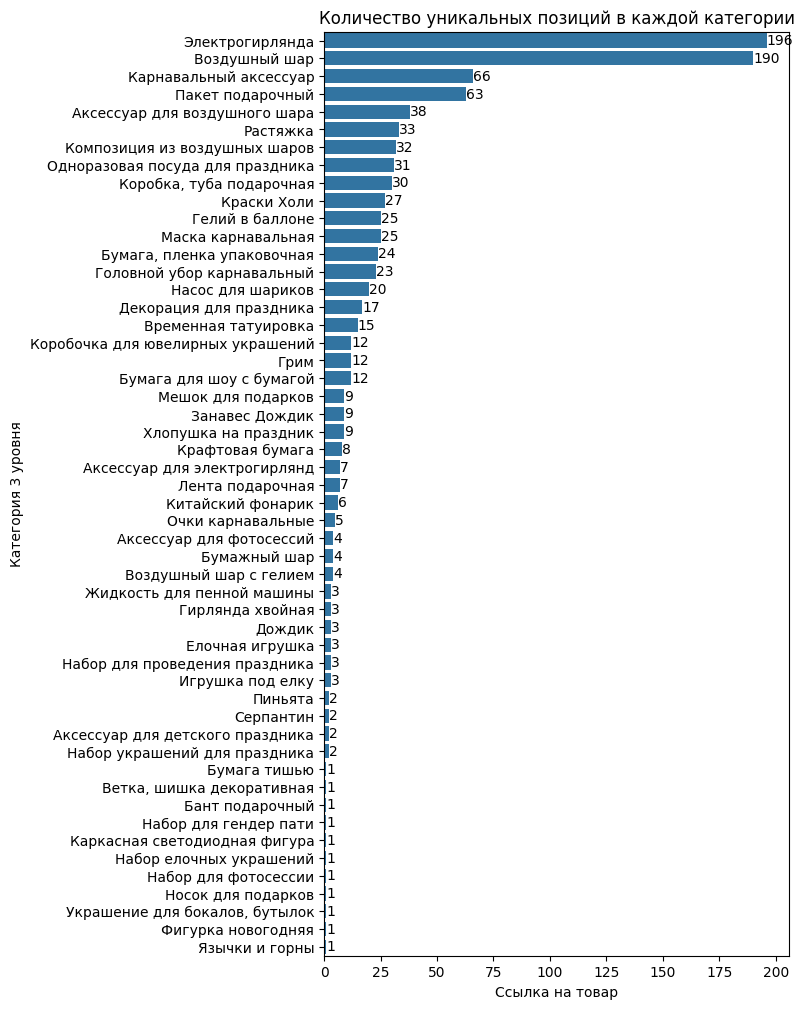

In [17]:
# Распределениe по категориям
f, ax = plt.subplots(figsize=(6, 12))
data = (
    df
    .groupby(['Категория 3 уровня'])
    .agg({
        'Ссылка на товар': 'nunique',
    })
    .sort_values('Ссылка на товар', ascending=False)
)

plt.title('Количество уникальных позиций в каждой категории')
sns.barplot(data, x='Ссылка на товар', y='Категория 3 уровня', orient='h')
ax.bar_label(ax.containers[0]);

In [18]:
# (
#     df
#     .groupby(['Категория 3 уровня', 'Признак товара'])
#     .agg({
#         'Ссылка на товар': 'nunique',
#     })
# )

 ## Оценка распределения по количеству продавцов в категории

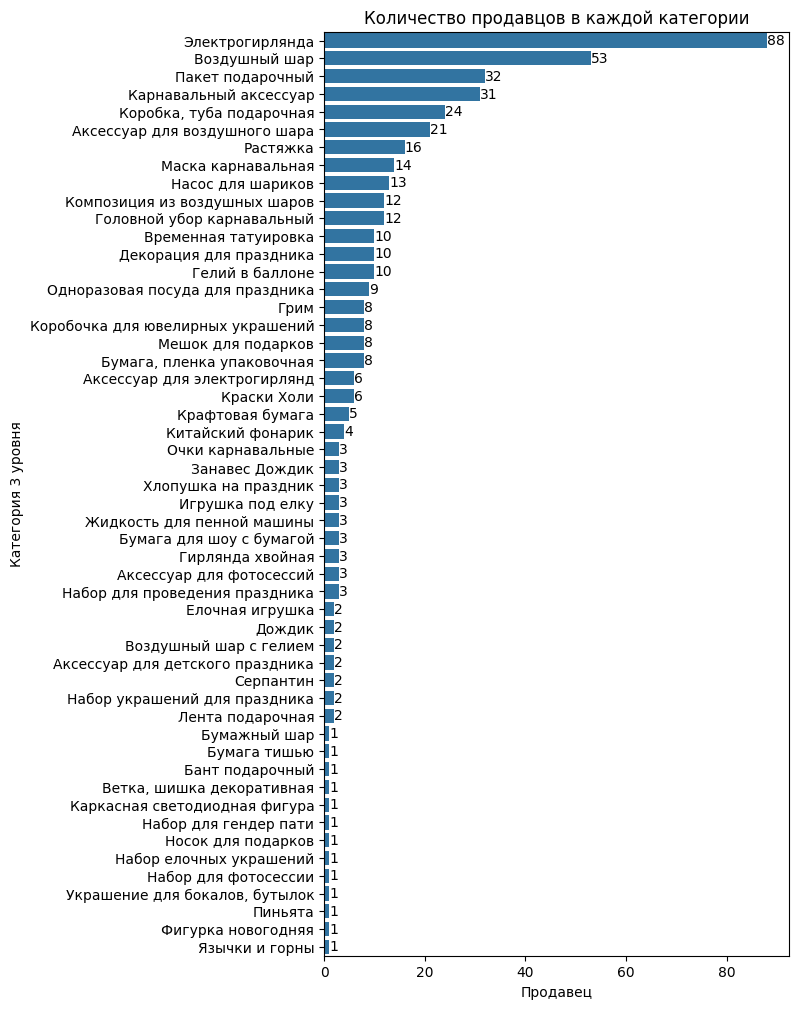

In [19]:
# Распределение по категориям
f, ax = plt.subplots(figsize=(6, 12))
data = (
    df
    .groupby(['Категория 3 уровня'])
    .agg({
        'Продавец': 'nunique',
    })
    .sort_values('Продавец', ascending=False)
)

plt.title('Количество продавцов в каждой категории')
sns.barplot(data, x='Продавец', y='Категория 3 уровня', orient='h')
ax.bar_label(ax.containers[0]);

 ## Среднее количество позиций на продавца в категории. Можно рассматривать как оценку конкурентости в категории, где больше - конкурентнее

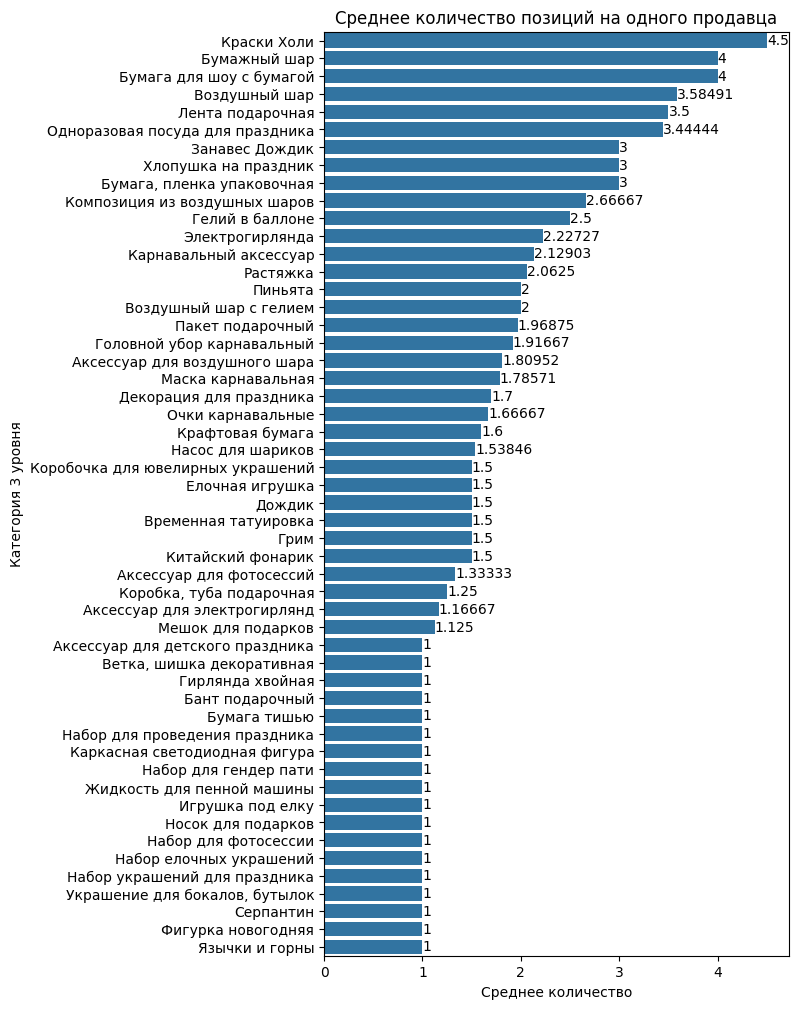

In [20]:
f, ax = plt.subplots(figsize=(6, 12))
data = (
    df
    .groupby(['Категория 3 уровня'])
    .agg({
        'Ссылка на товар': 'nunique',
        'Продавец': 'nunique',
    })
    .assign(
        coef = lambda x: x['Ссылка на товар'] / x['Продавец']
    )
    .sort_values('coef', ascending=False)
    .rename(columns={'coef': 'Среднее количество'})
)

plt.title('Среднее количество позиций на одного продавца')
sns.barplot(data, x='Среднее количество', y='Категория 3 уровня', orient='h', ax=ax)
ax.bar_label(ax.containers[0]);

In [21]:
# Оценка разнообразия ассортимента у продавцов
# (
#     df
#     .groupby(['Продавец'])
#     .agg({
#         'Ссылка на товар': 'nunique',
#         'Категория 3 уровня': ['nunique', lambda x: list(x.unique())]
#     })
#     .loc[lambda x: x[('Ссылка на товар', 'nunique')] > 5]
#     .sort_values(('Категория 3 уровня', 'nunique'), ascending=False)
# )

 ## Оценочное значение среднего Average Revenue per User для категорий.

 **Методика расчета**

 Комиссия категории зависит от категории 3го уровня и выбора FBO или FBS, но в среднем примерно 26%. НДС по УСН, только единый налог 6%, по обороту не учитывается. Тарифы на логистику по объему примерно 7% процентов от цены. Тарифы на логистику по времени доставки в соответствии с политикой Ozon. Доля рекламных расходов, конверсия в заказ в соответствии с исходными данными. Маржинальность, допустим, 25%. По итогу получается чистая прибыль с каждого показа. Категории, где представлено менее 5 товаров исключены за неполнотой предоставляемой картины

[Text(0, 0, '1.86'),
 Text(0, 0, '1.76'),
 Text(0, 0, '1.5'),
 Text(0, 0, '1.46'),
 Text(0, 0, '1.42'),
 Text(0, 0, '1.38'),
 Text(0, 0, '0.99'),
 Text(0, 0, '0.96'),
 Text(0, 0, '0.63'),
 Text(0, 0, '0.63'),
 Text(0, 0, '0.6'),
 Text(0, 0, '0.58'),
 Text(0, 0, '0.52'),
 Text(0, 0, '0.5'),
 Text(0, 0, '0.47'),
 Text(0, 0, '0.39'),
 Text(0, 0, '0.36'),
 Text(0, 0, '0.34'),
 Text(0, 0, '0.33'),
 Text(0, 0, '0.31'),
 Text(0, 0, '0.3'),
 Text(0, 0, '0.28'),
 Text(0, 0, '0.21'),
 Text(0, 0, '0.19'),
 Text(0, 0, '0.17'),
 Text(0, 0, '0.16'),
 Text(0, 0, '0.15')]

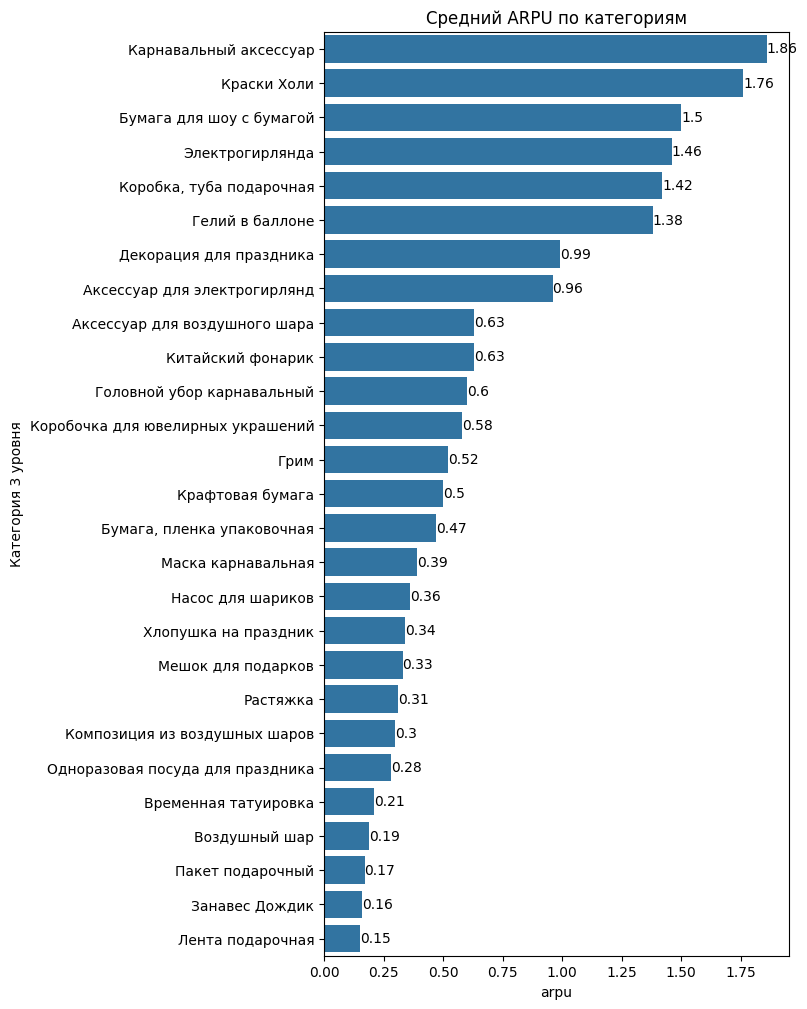

In [22]:
# Коммиссия категории 
category_comission = 0.26
# судя по всему УСН
nds = 0.06
logistics_costs= 0.07
margin = 0.25

def calc_delivery_speed_comission(val):
    d = dict(
        zip([29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61],
        [0.00, 0.25, 0.55, 0.80, 1.15, 1.40, 1.60, 1.80, 2.00, 2.20, 2.40, 2.55, 2.70, 2.85, 3.00, 3.15, 3.30, 3.45, 3.55, 3.65, 3.75, 3.80, 3.85, 3.87, 3.90, 3.92, 3.94, 3.95, 3.96, 3.97, 3.98, 3.99, 4.00])
    ) 
    return d.get(val, 4) * 0.01

data = (
    df
    .assign(
        delivery_speed_comission=lambda x: x['Ср. время доставки до покупателя, часы'].apply(calc_delivery_speed_comission)
        
    )
    .assign(
        arpu=(
            lambda x: x['Средняя цена, ₽'] * x['Доля выкупа, %'] * 
            0.01 * (1 - category_comission) * (1 - x['Доля рекламных расходов, %'] * 0.01) * 
            (1 - nds) * (1 - x['delivery_speed_comission']) * (1 - logistics_costs) * 
            (x['Конверсия из показа в заказ, %'] * 0.01) * margin
        )
    )
    [['Название товара', 'Ссылка на товар', 'Продавец', 'Категория 3 уровня', 'Средняя цена, ₽', 'Показы всего', 'arpu']]
    .groupby('Категория 3 уровня')
    .agg({
        'arpu': 'mean',
        'Ссылка на товар': 'nunique',
    })
    .round(2)
    .loc[lambda x: x['Ссылка на товар'] > 5]
    .drop(columns='Ссылка на товар')
    .sort_values('arpu', ascending=False)
)

f, ax = plt.subplots(figsize=(6, 12))
plt.title('Средний ARPU по категориям')
sns.barplot(data, x='arpu', y='Категория 3 уровня', orient='h')
ax.bar_label(ax.containers[0])

In [23]:
# data = (
#     df
#     .assign(
#         delivery_speed_comission=lambda x: x['Ср. время доставки до покупателя, часы'].apply(calc_delivery_speed_comission)
        
#     )
#     .assign(
#         arpu=(
#             lambda x: x['Средняя цена, ₽'] * x['Доля выкупа, %'] * 
#             0.01 * (1 - category_comission) * (1 - x['Доля рекламных расходов, %'] * 0.01) * 
#             (1 - nds) * (1 - x['delivery_speed_comission']) * (1 - logistics_costs) * 
#             (x['Конверсия из показа в заказ, %'] * 0.01) * margin
#         )
#     )
#     [['Название товара', 'Ссылка на товар', 'Продавец', 'Категория 3 уровня', 'Средняя цена, ₽', 'Показы всего', 'arpu']]
#     .groupby('Категория 3 уровня')
#     .agg({
#         'arpu': 'mean',
#         'Ссылка на товар': 'nunique',
#         'Показы всего': 'mean'
#     })
#     .assign(
#         expected_revenue=lambda x: x['Показы всего'] * x['arpu']
#     )
#     .loc[lambda x: x['Ссылка на товар'] > 5]
#     .drop(columns=['Ссылка на товар'])
#     .sort_values('expected_revenue', ascending=False)
# )

# f, ax = plt.subplots(figsize=(6, 12))
# plt.title('Средний ожидаемый доход по категориям')
# sns.barplot(data, x='expected_revenue', y='Категория 3 уровня', orient='h')
# ax.bar_label(ax.containers[0])


 ## Ожидаемая прибыль для каждой категории

In [24]:
(
    df
    .assign(
        delivery_speed_comission=lambda x: x['Ср. время доставки до покупателя, часы'].apply(calc_delivery_speed_comission)
        
    )
    .assign(
        arpu=(
            lambda x: x['Средняя цена, ₽'] * x['Доля выкупа, %'] * 
            0.01 * (1 - category_comission) * (1 - x['Доля рекламных расходов, %'] * 0.01) * 
            (1 - nds) * (1 - x['delivery_speed_comission']) * (1 - logistics_costs) * 
            (x['Конверсия из показа в заказ, %'] * 0.01) * margin
        )
    )
    [['Название товара', 'Ссылка на товар', 'Продавец', 'Категория 3 уровня', 'Средняя цена, ₽', 'Показы всего', 'arpu']]
    .groupby('Категория 3 уровня')
    .agg({
        'arpu': 'mean',
        'Ссылка на товар': 'nunique',
        'Показы всего': 'mean'
    })
    .assign(
        expected_revenue=lambda x: x['Показы всего'] * x['arpu']
    )
    .loc[lambda x: x['Ссылка на товар'] > 5]
    .sort_values('expected_revenue', ascending=False)
)

,arpu,Ссылка на товар,Показы всего,expected_revenue
Категория 3 уровня,,,,
Электрогирлянда,1.460904,196,215136.387755,314293.712830
Карнавальный аксессуар,1.863408,66,114641.500000,213623.848365
Аксессуар для воздушного шара,0.626685,38,319543.631579,200253.107493
Декорация для праздника,0.985559,17,174414.882353,171896.083050
"Бумага, пленка упаковочная",0.467302,24,302197.791667,141217.638786
"Коробка, туба подарочная",1.418956,30,94149.733333,133594.322586
Насос для шариков,0.356890,20,345851.450000,123431.017758
Краски Холи,1.763289,27,68810.703704,121333.137776
Гелий в баллоне,1.379780,25,62322.120000,85990.804667


 # Вывод

 * В качестве метрики для подбора был выбран *Average revenue per user*. По сути, данная метрика показывает прибыль с одного просмотра товара. Способ расчета в данном случае делает эту прибыль чистой(после всех комиссий и налогов).

 * Выбранная метрика легко масштабируется и предоставляет удобный способ оценки ожидаемой прибыли по категории

 * Принимая во внимание сильную экспертизу в дизайне и возможность закупать товар большими партиями, наиболее подходящими категориями 3 уровня для дальнейнешо развития я нахожу "Карнавальный аксессуар", "Коробка, туба подарочная", "Китайский фонарик", "Головной убор карнавальный", "Крафтовая бумага".

 * Каждая из выбранных категорий предоставляет достаточный простор для творчества команды дизайнеров и неплохую ключевую метрику.

 * Другие категории либо уже представлены в ассортименте магазина(Растяжка; Композиция из воздушшных шаров), либо являются непрофильными(Электрогирлянда; Гелий в балоне), либо не содержат достаточно данных для выводов